In [1]:
import json
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import os
from google.colab import files

In [2]:
# =========================
# 1. ЗАГРУЗКА И РАСПАКОВКА ZIP
# =========================
print("📤 Загрузите zip файл с аннотациями...")
uploaded = files.upload()

# Находим имя загруженного zip файла
zip_filename = list(uploaded.keys())[0]
print(f"Файл загружен: {zip_filename}")

# Создаем папку для распаковки
extract_path = "annotations"
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Распаковано в папку: {extract_path}")

📤 Загрузите zip файл с аннотациями...


Saving архив_gigachat.zip to архив_gigachat.zip
Файл загружен: архив_gigachat.zip
Распаковано в папку: annotations


In [3]:
# =========================
# 2. ЗАГРУЗКА ВСЕХ JSON ФАЙЛОВ
# =========================
print("\n📂 Загрузка JSON файлов...")

data = []

for filename in os.listdir(extract_path):
    if filename.endswith('.json'):
        filepath = os.path.join(extract_path, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            try:
                record = json.load(f)

                # Определяем источник (человек или модель)
                source = record.get("source", "неизвестно")
                text_column = record.get("text_column", "")

                if source == "неизвестно" or source.startswith("человек_") or source == "человек":
                    if text_column.startswith("Описание_"):
                        source = "человек"
                    elif any(model in text_column for model in ["Gemma", "Qwen", "Yandex VML"]):
                        source = "модель"
                    else:
                        source = "неопределено"
                else:
                    if source.startswith("человек_"):
                        source = "человек"
                    elif source == "модель":
                        source = "модель"

                # Для каждого ключевого слова создаем строку
                for ann in record.get("annotations", []):
                    row = {
                        "image_id": record["image_id"],
                        "text_column": text_column,
                        "source": source,
                        "keyword": ann.get("keyword", ""),
                        "context": ann.get("context", ""),
                        "cognitive_type": ann.get("cognitive_type", "unknown"),
                        "subtype": ann.get("subtype", "unknown")
                    }
                    data.append(row)

            except Exception as e:
                print(f"Ошибка в файле {filename}: {e}")

df = pd.DataFrame(data)
print(f"\n✅ Загружено {len(df)} аннотаций")
print(f"Уникальных изображений: {df['image_id'].nunique()}")
print(f"Источники: {df['source'].unique().tolist()}")
print(f"Cognitive types: {df['cognitive_type'].unique().tolist()}")


📂 Загрузка JSON файлов...

✅ Загружено 194306 аннотаций
Уникальных изображений: 895
Источники: ['модель', 'человек']
Cognitive types: ['interpretive', 'perceptual']


In [4]:
# =========================
# 3. СОХРАНЕНИЕ ДАТАФРЕЙМА
# =========================
df.to_csv("annotations_df_gigachat.csv", index=False)
print("\n💾 Датафрейм сохранен как annotations_df.csv")
print(df.head(10))


💾 Датафрейм сохранен как annotations_df.csv
  image_id text_column  source     keyword                  context  \
0   id_706  Yandex VML  модель     картина           картина маслом   
1   id_706  Yandex VML  модель      маслом           картина маслом   
2   id_706  Yandex VML  модель     портрет  портрет молодой женщины   
3   id_706  Yandex VML  модель     молодой  портрет молодой женщины   
4   id_706  Yandex VML  модель     женщины  портрет молодой женщины   
5   id_706  Yandex VML  модель       белая             белая шляпка   
6   id_706  Yandex VML  модель      шляпка             белая шляпка   
7   id_706  Yandex VML  модель  украшенная  украшенная синей лентой   
8   id_706  Yandex VML  модель       синей  украшенная синей лентой   
9   id_706  Yandex VML  модель      лентой  украшенная синей лентой   

  cognitive_type               subtype  
0   interpretive     artistic property  
1   interpretive  aesthetic evaluation  
2     perceptual           person type  
3     per

In [ ]:
# =========================
# 4. БАЗОВАЯ СТАТИСТИКА
# =========================
print("\n" + "="*60)
print("📊 БАЗОВАЯ СТАТИСТИКА")
print("="*60)

# Статистика по источникам
source_stats = df.groupby('source').agg({
    'keyword': 'count',
    'image_id': 'nunique'
}).rename(columns={'keyword': 'total_keywords', 'image_id': 'unique_images'})
print("\nСтатистика по источникам:")
print(source_stats)

# Распределение cognitive_type
print("\nРаспределение cognitive_type:")
cognitive_dist = pd.crosstab(df['source'], df['cognitive_type'], normalize='index') * 100
print(cognitive_dist.round(1))


📊 БАЗОВАЯ СТАТИСТИКА

Статистика по источникам:
         total_keywords  unique_images
source                                
модель           104794            895
человек           89512            895

Распределение cognitive_type:
cognitive_type  interpretive  perceptual
source                                  
модель                  36.4        63.6
человек                 13.0        87.0


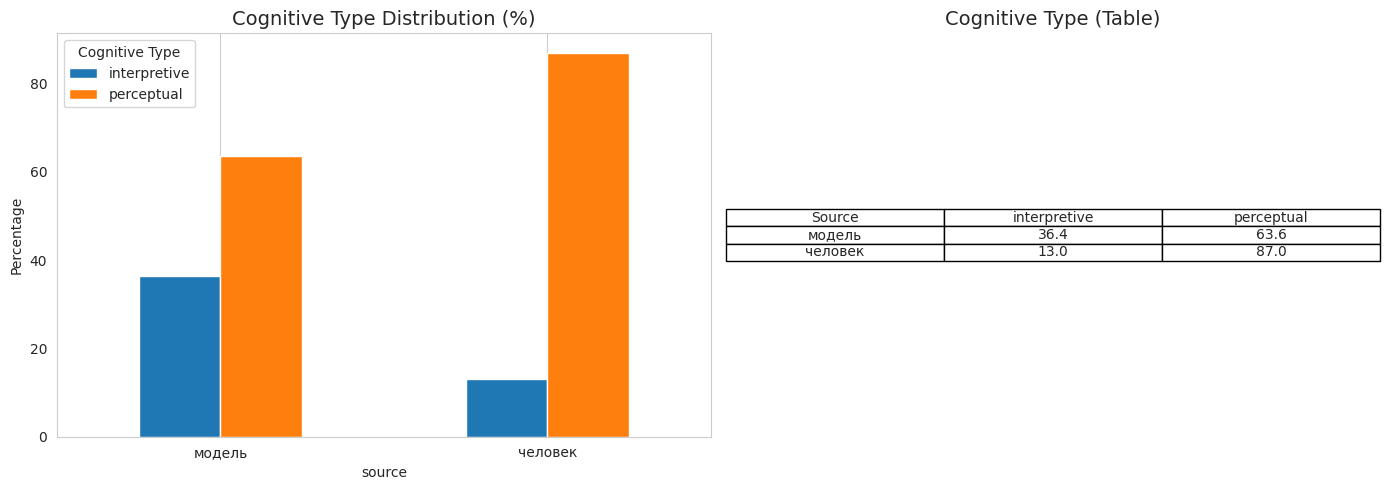

In [ ]:
# =========================
# 5. ВИЗУАЛИЗАЦИИ
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 5.1 Cognitive Type распределение
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cognitive_counts = df.groupby(['source', 'cognitive_type']).size().unstack(fill_value=0)
cognitive_counts_pct = cognitive_counts.div(cognitive_counts.sum(axis=1), axis=0) * 100

cognitive_counts_pct.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Cognitive Type Distribution (%)', fontsize=14)
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Cognitive Type')
axes[0].grid(axis='y')

axes[1].axis('tight')
axes[1].axis('off')
table_data = cognitive_counts_pct.round(1).reset_index().values.tolist()
table_cols = ['Source'] + list(cognitive_counts_pct.columns)
table = axes[1].table(cellText=table_data, colLabels=table_cols,
                      cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1].set_title('Cognitive Type (Table)', fontsize=14)

plt.tight_layout()
plt.savefig('cognitive_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


🏷️ SUBTYPE АНАЛИЗ

🔍 ТОП-10 SUBTYPES (PERCEPTUAL) - ЧЕЛОВЕК:
subtype
clothing item           12795
color                    9316
none                     8973
person property          8761
spatial                  8097
object property          7641
action                   5760
person type              5651
nature and landscape     4924
architecture             2836

🤖 ТОП-10 SUBTYPES (PERCEPTUAL) - МОДЕЛЬ:
subtype
color                   11543
none                    10872
clothing item            9041
spatial                  6417
nature and landscape     5975
object property          5640
action                   4460
person property          3895
person type              3616
architecture             2926

🔍 ТОП-10 SUBTYPES (INTERPRETIVE) - ЧЕЛОВЕК:
subtype
social role             3411
activity                2539
artistic property       1253
status marker           1227
religion                1143
aesthetic evaluation     747
emotion                  643
mood                    

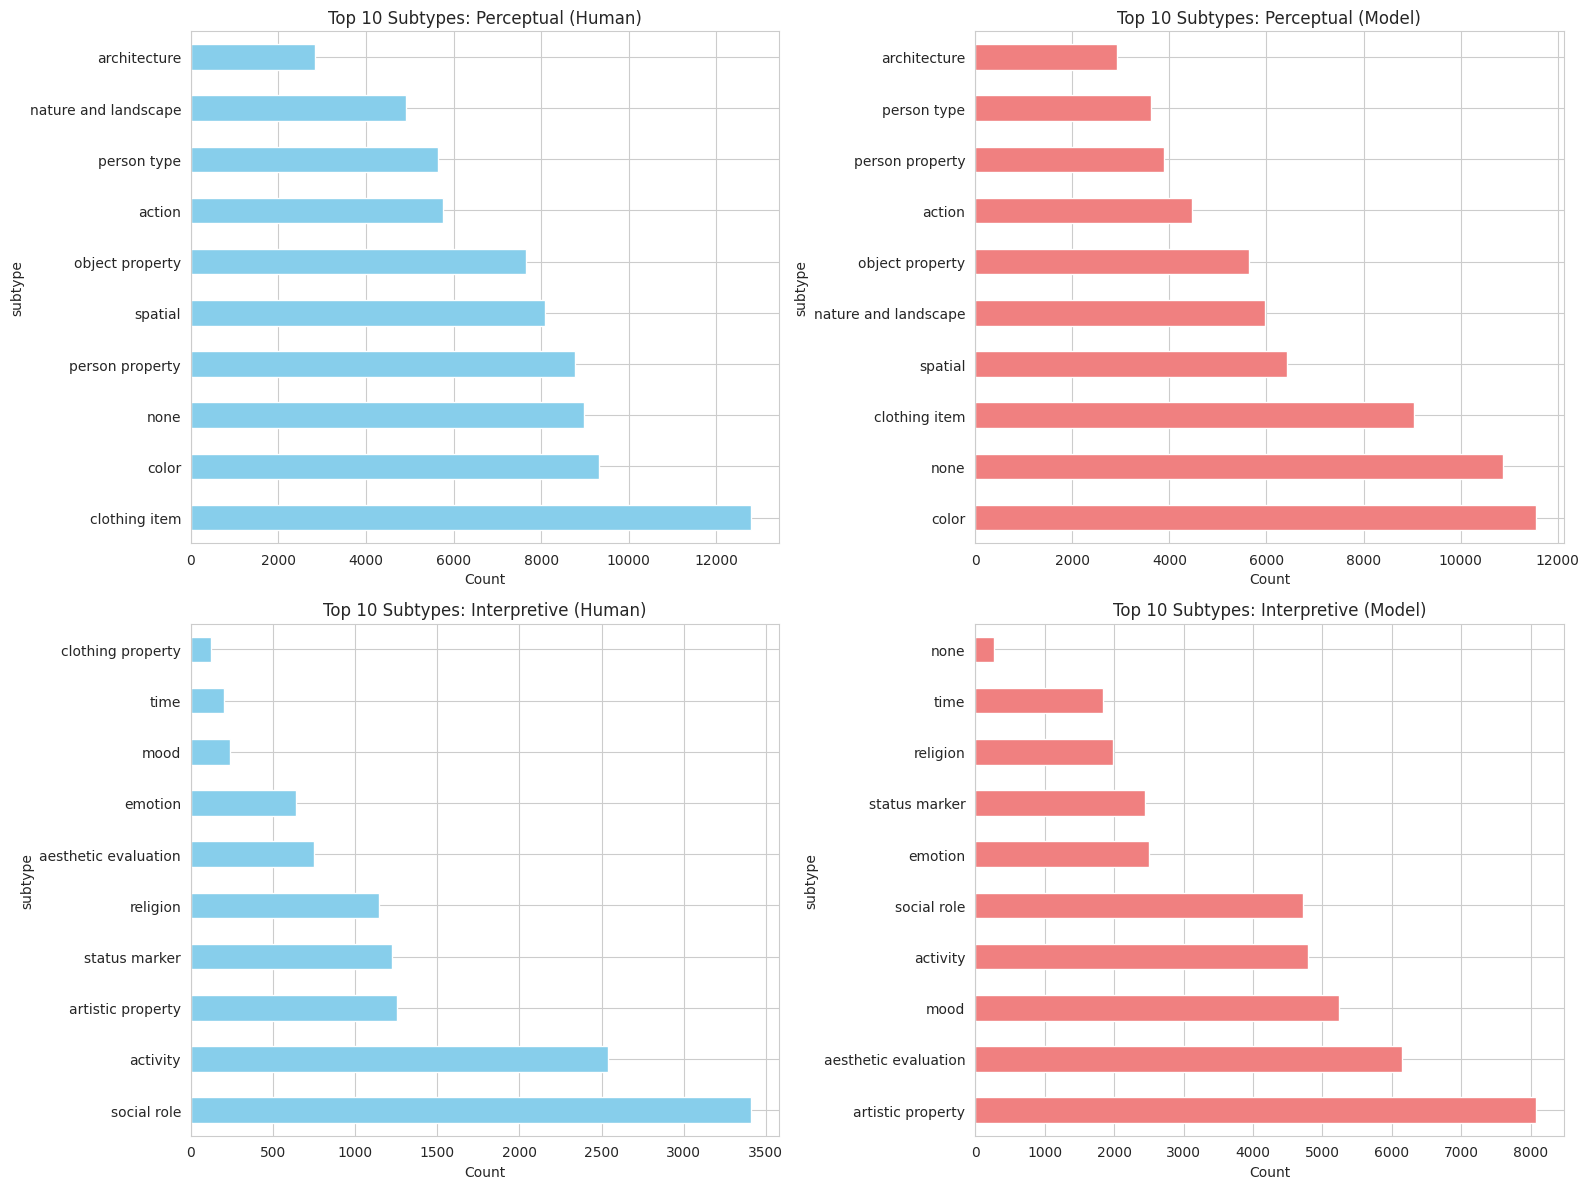

In [ ]:
# =========================
# 6. SUBTYPE АНАЛИЗ (по cognitive_type)
# =========================
print("\n" + "="*60)
print("🏷️ SUBTYPE АНАЛИЗ")
print("="*60)

# Определяем допустимые subtype для каждого cognitive_type
PERCEPTUAL_SUBTYPES = [
    "person type", "person property", "clothing item", "color",
    "nature and landscape", "architecture", "spatial", "animal",
    "action", "item", "object property", "none"
]

INTERPRETIVE_SUBTYPES = [
    "emotion", "mood", "social role", "time", "religion",
    "artistic property", "color", "activity", "clothing property",
    "aesthetic evaluation", "status marker", "none"
]

# Для perceptual (только где есть данные)
df_perceptual = df[df['cognitive_type'] == 'perceptual']

if not df_perceptual.empty:
    perceptual_human = df_perceptual[df_perceptual['source'] == 'человек']['subtype'].value_counts().head(10)
    perceptual_model = df_perceptual[df_perceptual['source'] == 'модель']['subtype'].value_counts().head(10)

    print("\n🔍 ТОП-10 SUBTYPES (PERCEPTUAL) - ЧЕЛОВЕК:")
    print(perceptual_human.to_string())
    print("\n🤖 ТОП-10 SUBTYPES (PERCEPTUAL) - МОДЕЛЬ:")
    print(perceptual_model.to_string())
else:
    print("\nНет данных для cognitive_type='perceptual'")

# Для interpretive
df_interpretive = df[df['cognitive_type'] == 'interpretive']

if not df_interpretive.empty:
    interpretive_human = df_interpretive[df_interpretive['source'] == 'человек']['subtype'].value_counts().head(10)
    interpretive_model = df_interpretive[df_interpretive['source'] == 'модель']['subtype'].value_counts().head(10)

    print("\n🔍 ТОП-10 SUBTYPES (INTERPRETIVE) - ЧЕЛОВЕК:")
    print(interpretive_human.to_string())
    print("\n🤖 ТОП-10 SUBTYPES (INTERPRETIVE) - МОДЕЛЬ:")
    print(interpretive_model.to_string())
else:
    print("\nНет данных для cognitive_type='interpretive'")

# Визуализация subtypes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Perceptual - Human
if not df_perceptual.empty and not perceptual_human.empty:
    perceptual_human.plot(kind='barh', ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Top 10 Subtypes: Perceptual (Human)', fontsize=12)
else:
    axes[0,0].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[0,0].set_title('Top 10 Subtypes: Perceptual (Human)', fontsize=12)
axes[0,0].set_xlabel('Count')

# Perceptual - Model
if not df_perceptual.empty and not perceptual_model.empty:
    perceptual_model.plot(kind='barh', ax=axes[0,1], color='lightcoral')
    axes[0,1].set_title('Top 10 Subtypes: Perceptual (Model)', fontsize=12)
else:
    axes[0,1].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[0,1].set_title('Top 10 Subtypes: Perceptual (Model)', fontsize=12)
axes[0,1].set_xlabel('Count')

# Interpretive - Human
if not df_interpretive.empty and not interpretive_human.empty:
    interpretive_human.plot(kind='barh', ax=axes[1,0], color='skyblue')
    axes[1,0].set_title('Top 10 Subtypes: Interpretive (Human)', fontsize=12)
else:
    axes[1,0].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[1,0].set_title('Top 10 Subtypes: Interpretive (Human)', fontsize=12)
axes[1,0].set_xlabel('Count')

# Interpretive - Model
if not df_interpretive.empty and not interpretive_model.empty:
    interpretive_model.plot(kind='barh', ax=axes[1,1], color='lightcoral')
    axes[1,1].set_title('Top 10 Subtypes: Interpretive (Model)', fontsize=12)
else:
    axes[1,1].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[1,1].set_title('Top 10 Subtypes: Interpretive (Model)', fontsize=12)
axes[1,1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('subtypes_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =========================
# 7. ПОДГОТОВКА ДАННЫХ ДЛЯ СРАВНЕНИЯ
# =========================
print("\n" + "="*60)
print("📊 ПОДГОТОВКА ДАННЫХ ДЛЯ СРАВНЕНИЯ")
print("="*60)

# Создаем сводные таблицы для всех subtype (без разделения по cognitive_type)
subtype_counts = df.groupby(['subtype', 'source']).size().unstack(fill_value=0)

# Приводим названия колонок к нужному формату
if 'человек' in subtype_counts.columns:
    subtype_counts['human_count'] = subtype_counts['человек']
else:
    subtype_counts['human_count'] = 0

if 'модель' in subtype_counts.columns:
    subtype_counts['model_count'] = subtype_counts['модель']
else:
    subtype_counts['model_count'] = 0

# Сортируем по общему количеству
subtype_counts['total'] = subtype_counts['human_count'] + subtype_counts['model_count']
subtype_counts_sorted = subtype_counts.sort_values('total', ascending=False).reset_index()

# Вычисляем общие subtype (встречаются и у людей, и у моделей)
all_df = subtype_counts_sorted[['subtype', 'human_count', 'model_count']].copy()
common_all = all_df[(all_df['human_count'] > 0) & (all_df['model_count'] > 0)]

print(f"Всего уникальных subtype: {len(all_df)}")
print(f"Общих subtype (есть у обоих): {len(common_all)}")
print(f"Процент общих: {len(common_all)/len(all_df)*100:.1f}%")

# Для perceptual
df_perceptual = df[df['cognitive_type'] == 'perceptual']
if not df_perceptual.empty:
    perc_counts = df_perceptual.groupby(['subtype', 'source']).size().unstack(fill_value=0)
    if 'человек' in perc_counts.columns:
        perc_counts['human_count'] = perc_counts['человек']
    else:
        perc_counts['human_count'] = 0
    if 'модель' in perc_counts.columns:
        perc_counts['model_count'] = perc_counts['модель']
    else:
        perc_counts['model_count'] = 0
    perc_counts['total'] = perc_counts['human_count'] + perc_counts['model_count']
    perc_counts_sorted = perc_counts.sort_values('total', ascending=False).reset_index()
    perc_df = perc_counts_sorted[['subtype', 'human_count', 'model_count']].copy()
    common_perc = perc_df[(perc_df['human_count'] > 0) & (perc_df['model_count'] > 0)]
    print(f"\nPerceptual - уникальных: {len(perc_df)}, общих: {len(common_perc)}")
else:
    perc_df = pd.DataFrame(columns=['subtype', 'human_count', 'model_count'])
    common_perc = pd.DataFrame()

# Для interpretive
df_interpretive = df[df['cognitive_type'] == 'interpretive']
if not df_interpretive.empty:
    interp_counts = df_interpretive.groupby(['subtype', 'source']).size().unstack(fill_value=0)
    if 'человек' in interp_counts.columns:
        interp_counts['human_count'] = interp_counts['человек']
    else:
        interp_counts['human_count'] = 0
    if 'модель' in interp_counts.columns:
        interp_counts['model_count'] = interp_counts['модель']
    else:
        interp_counts['model_count'] = 0
    interp_counts['total'] = interp_counts['human_count'] + interp_counts['model_count']
    interp_counts_sorted = interp_counts.sort_values('total', ascending=False).reset_index()
    interp_df = interp_counts_sorted[['subtype', 'human_count', 'model_count']].copy()
    common_interp = interp_df[(interp_df['human_count'] > 0) & (interp_df['model_count'] > 0)]
    print(f"Interpretive - уникальных: {len(interp_df)}, общих: {len(common_interp)}")
else:
    interp_df = pd.DataFrame(columns=['subtype', 'human_count', 'model_count'])
    common_interp = pd.DataFrame()


📊 ПОДГОТОВКА ДАННЫХ ДЛЯ СРАВНЕНИЯ
Всего уникальных subtype: 22
Общих subtype (есть у обоих): 22
Процент общих: 100.0%

Perceptual - уникальных: 12, общих: 12
Interpretive - уникальных: 12, общих: 12


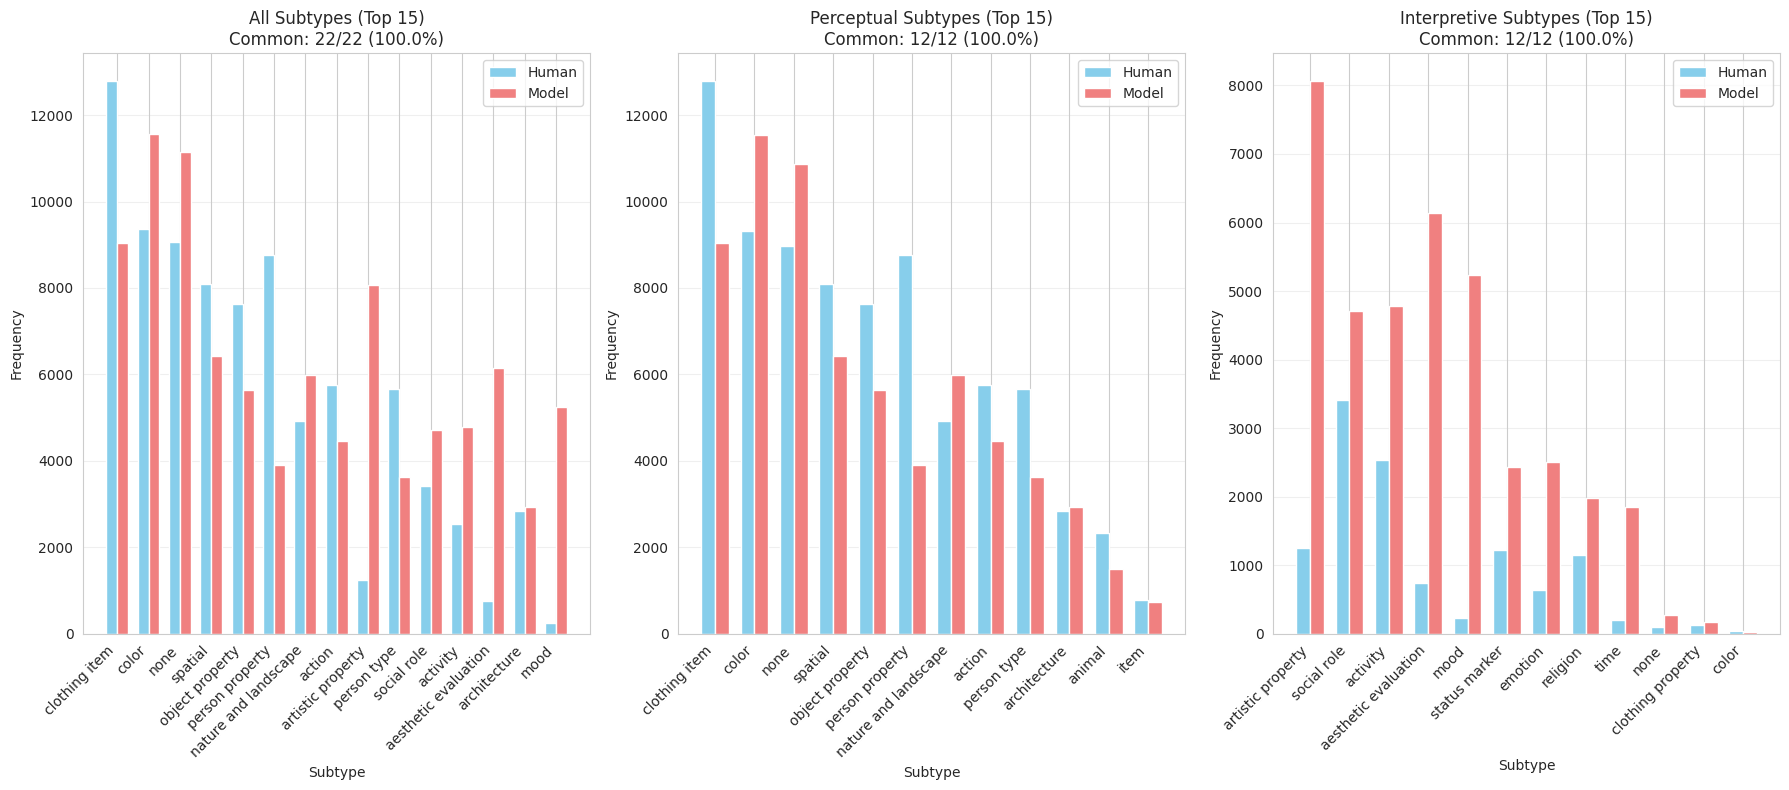

In [ ]:
# =========================
# 8. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Топ-15 для всех subtypes
if not all_df.empty:
    top_all = all_df.head(15)
    x = range(len(top_all))
    width = 0.35

    axes[0].bar([i - width/2 for i in x], top_all['human_count'], width, label='Human', color='skyblue')
    axes[0].bar([i + width/2 for i in x], top_all['model_count'], width, label='Model', color='lightcoral')
    axes[0].set_xlabel('Subtype')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'All Subtypes (Top 15)\nCommon: {len(common_all)}/{len(all_df)} ({len(common_all)/len(all_df)*100:.1f}%)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(top_all['subtype'], rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[0].set_title('All Subtypes', fontsize=12)

# Топ-15 для perceptual
if not perc_df.empty:
    top_perc = perc_df.head(15)
    x_perc = range(len(top_perc))
    axes[1].bar([i - width/2 for i in x_perc], top_perc['human_count'], width, label='Human', color='skyblue')
    axes[1].bar([i + width/2 for i in x_perc], top_perc['model_count'], width, label='Model', color='lightcoral')
    axes[1].set_xlabel('Subtype')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Perceptual Subtypes (Top 15)\nCommon: {len(common_perc)}/{len(perc_df)} ({len(common_perc)/len(perc_df)*100:.1f}%)')
    axes[1].set_xticks(x_perc)
    axes[1].set_xticklabels(top_perc['subtype'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No perceptual data', ha='center', va='center')
    axes[1].set_title('Perceptual Subtypes', fontsize=12)

# Топ-15 для interpretive
if not interp_df.empty:
    top_interp = interp_df.head(15)
    x_interp = range(len(top_interp))
    axes[2].bar([i - width/2 for i in x_interp], top_interp['human_count'], width, label='Human', color='skyblue')
    axes[2].bar([i + width/2 for i in x_interp], top_interp['model_count'], width, label='Model', color='lightcoral')
    axes[2].set_xlabel('Subtype')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'Interpretive Subtypes (Top 15)\nCommon: {len(common_interp)}/{len(interp_df)} ({len(common_interp)/len(interp_df)*100:.1f}%)')
    axes[2].set_xticks(x_interp)
    axes[2].set_xticklabels(top_interp['subtype'], rotation=45, ha='right')
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No interpretive data', ha='center', va='center')
    axes[2].set_title('Interpretive Subtypes', fontsize=12)

plt.tight_layout()
plt.savefig('subtypes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =========================
# 9. СОХРАНЕНИЕ В EXCEL
# =========================
with pd.ExcelWriter('analysis_results.xlsx', engine='openpyxl') as writer:
    # Основная статистика
    source_stats.to_excel(writer, sheet_name='Source_Stats')
    cognitive_counts_pct.to_excel(writer, sheet_name='Cognitive_Type')

    # Subtype анализ
    all_df.to_excel(writer, sheet_name='All_Subtypes', index=False)

    if not perc_df.empty:
        perc_df.to_excel(writer, sheet_name='Perceptual_Subtypes', index=False)

    if not interp_df.empty:
        interp_df.to_excel(writer, sheet_name='Interpretive_Subtypes', index=False)

    # Статистика совпадений
    summary = pd.DataFrame({
        'Category': ['All', 'Perceptual', 'Interpretive'],
        'Total_Subtypes': [len(all_df), len(perc_df) if not perc_df.empty else 0, len(interp_df) if not interp_df.empty else 0],
        'Common': [len(common_all), len(common_perc) if not perc_df.empty else 0, len(common_interp) if not interp_df.empty else 0],
        'Only_Human': [len(only_human_all), len(only_human_perc) if not perc_df.empty else 0, len(only_human_interp) if not interp_df.empty else 0],
        'Only_Model': [len(only_model_all), len(only_model_perc) if not perc_df.empty else 0, len(only_model_interp) if not interp_df.empty else 0],
        'Overlap_%': [
            len(common_all)/len(all_df)*100,
            len(common_perc)/len(perc_df)*100 if not perc_df.empty else 0,
            len(common_interp)/len(interp_df)*100 if not interp_df.empty else 0
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

    # Сырые данные (опционально, может быть большим)
    # df.to_excel(writer, sheet_name='Raw_Data', index=False)

print("\n✅ Результаты сохранены в analysis_results.xlsx")
print(f"   - Всего subtypes: {len(all_df)}")
print(f"   - Совпало: {len(common_all)} ({len(common_all)/len(all_df)*100:.1f}%)")
print(f"   - Только у человека: {len(only_human_all)}")
print(f"   - Только у модели: {len(only_model_all)}")

NameError: name 'only_human_all' is not defined

In [ ]:
# =========================
# 10. СОХРАНЕНИЕ ГРАФИКОВ И СКАЧИВАНИЕ
# =========================
import zipfile

# Сохраняем все графики в zip
with zipfile.ZipFile('visualizations.zip', 'w') as zipf:
    zipf.write('cognitive_type_analysis.png')
    zipf.write('subtypes_analysis.png')
    zipf.write('subtypes_comparison.png')

print("\n✅ Графики сохранены в visualizations.zip")

# Скачиваем результаты
files.download('annotations_df.csv')
files.download('analysis_results.xlsx')
files.download('visualizations.zip')

print("\n🎉 Анализ завершен! Файлы скачаны.")


✅ Графики сохранены в visualizations.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Анализ завершен! Файлы скачаны.
